# PP-OCRv6 tier analysis — tiny vs small vs medium

Run the three PP-OCRv6 tiers on your documents, **fully offline**, and analyse
**how well each one reads** — not how fast it runs.

What we look at:
1. **Extracted text** — per-line and assembled reading-order text, per tier
2. **Confidence** — mean confidence and which lines the model is unsure about
3. **Detected line count** — how the tiers differ in segmentation

This notebook is **self-contained**: the bootstrap cell below downloads the Paddle
models on first run if they're not already staged locally, then everything runs
**offline**. Subsequent runs touch no network.

## 0. Install dependencies

Run **once** per environment (needs internet). PP-OCRv6 requires `paddleocr>=3.7`
and the PaddlePaddle **3.x** inference engine. The CPU build of PaddlePaddle is
pulled from the official Paddle index; everything else from PyPI.

> GPU? Swap the PaddlePaddle line for the CUDA build, e.g.
> `paddlepaddle-gpu==3.2.0 -i https://www.paddlepaddle.org.cn/packages/stable/cu126/`
> and set `DEVICE = 'gpu'` in the config cell. Restart the kernel after installing.

In [1]:
import sys

# PaddlePaddle 3.x CPU inference engine (from the official Paddle index).
# For GPU, replace with the matching paddlepaddle-gpu wheel + CUDA index.
!{sys.executable} -m pip install --upgrade pip
!{sys.executable} -m pip install "paddlepaddle==3.2.0" -i https://www.paddlepaddle.org.cn/packages/stable/cpu/

# PaddleOCR (>=3.7 for PP-OCRv6) + the analysis deps used below.
# pypdfium2 rasterises PDF pages to images (pure-Python, no poppler needed).
!{sys.executable} -m pip install \
    "paddleocr>=3.7" \
    numpy \
    pandas \
    pillow \
    pypdfium2 \
    matplotlib

print('\ndependencies installed — restart the kernel if any package was upgraded.')

Looking in indexes: https://www.paddlepaddle.org.cn/packages/stable/cpu/

dependencies installed — restart the kernel if any package was upgraded.


## 1. Config — edit these


In [2]:
from pathlib import Path
from datetime import datetime

ROOT = Path.cwd().parent
MODELS = ROOT / 'models' / 'paddle'
DOCS_DIR = ROOT / 'data' / 'documents'

TIERS = ['tiny', 'small', 'medium']   # tiers to compare
DEVICE = 'cpu'                         # 'gpu' if you have paddlepaddle-gpu

PDF_DPI = 200     # rasterisation resolution for PDF pages (higher = sharper, slower)
LOW_CONF = 0.90   # lines below this confidence are flagged as "unsure"

# Extracted-text results are stamped with the run's date+time.
ARTIFACTS_DIR = ROOT / 'data' / 'artifacts'
RESULTS_STEM = 'ocr_analysis'

ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_CSV = ARTIFACTS_DIR / f"{RESULTS_STEM}_{datetime.now():%Y%m%d_%H%M%S}.csv"


print('models:', MODELS)
print('docs  :', DOCS_DIR)
print('root:', ROOT)
print('results:', RESULTS_CSV)

models: /home/friend/rag-poc/models/paddle
docs  : /home/friend/rag-poc/data/documents
root: /home/friend/rag-poc
results: /home/friend/rag-poc/data/artifacts/ocr_analysis_20260625_134914.csv


## 2. Offline guard + imports

Passing explicit local `*_model_dir` paths and disabling the auxiliary modules
(doc orientation / unwarping / textline orientation) keeps PaddleOCR from
reaching for anything it would otherwise download.


In [4]:
import os, gc
import numpy as np, pandas as pd
from PIL import Image

# Best-effort: discourage any version/telemetry network calls.
os.environ.setdefault('HUB_DATASET_ENDPOINT', '')
os.environ.setdefault('PADDLE_PDX_DISABLE_DEV_MODE', '1')

from paddleocr import PaddleOCR

def tier_dirs(tier):
    det = MODELS / f'pp_ocrv6_{tier}_det'
    rec = MODELS / f'pp_ocrv6_{tier}_rec'
    assert det.is_dir(), f'missing {det} — run scripts/fetch_models.sh'
    assert rec.is_dir(), f'missing {rec} — run scripts/fetch_models.sh'
    return det, rec

/home/friend/rag-poc/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2b. Bootstrap models — first run downloads, then offline

Idempotent: for each tier, if `models/paddle/pp_ocrv6_<tier>_{det,rec}` already exists it is **skipped**. Otherwise the model is fetched into PaddleOCR's cache and copied locally. After this cell, the rest of the notebook is fully offline.

> Needs internet **only** on the first run (or when a tier is missing). Requires `paddleocr>=3.7` for PP-OCRv6.


In [5]:
import shutil, tempfile

PDX_CACHE = Path(os.environ.get('PADDLE_PDX_CACHE_HOME', str(Path.home() / '.paddlex'))) / 'official_models'

def _tier_present(tier):
    det = MODELS / f'pp_ocrv6_{tier}_det'
    rec = MODELS / f'pp_ocrv6_{tier}_rec'
    return (det.is_dir() and any(det.iterdir())) and (rec.is_dir() and any(rec.iterdir()))

def _download_tier(tier):
    MODELS.mkdir(parents=True, exist_ok=True)
    det_name, rec_name = f'PP-OCRv6_{tier}_det', f'PP-OCRv6_{tier}_rec'
    blank = Path(tempfile.gettempdir()) / '_ppocr_blank.png'
    Image.fromarray(np.zeros((32, 32, 3), dtype=np.uint8)).save(blank)
    # Instantiating with model names triggers the one-time download into PDX_CACHE.
    o = PaddleOCR(
        text_detection_model_name=det_name,
        text_recognition_model_name=rec_name,
        use_doc_orientation_classify=False,
        use_doc_unwarping=False,
        use_textline_orientation=False,
        device=DEVICE,
    )
    o.predict(str(blank))   # forces weights to be materialised in cache
    del o; gc.collect()
    for name, sub in [(det_name, 'det'), (rec_name, 'rec')]:
        src = PDX_CACHE / name
        dst = MODELS / f'pp_ocrv6_{tier}_{sub}'
        if not src.is_dir():
            raise FileNotFoundError(
                f'expected cached model at {src} — ensure paddleocr>=3.7 supports PP-OCRv6')
        dst.mkdir(parents=True, exist_ok=True)
        for f in src.iterdir():
            if f.is_file(): shutil.copy2(f, dst / f.name)

for tier in TIERS:
    if _tier_present(tier):
        print(f'[skip]     {tier:6s} already staged at {MODELS}/pp_ocrv6_{tier}_*')
    else:
        print(f'[download] {tier:6s} ...')
        _download_tier(tier)
        print(f'[done]     {tier:6s}')
print('\nmodels ready — offline from here.')

[skip]     tiny   already staged at /home/friend/rag-poc/models/paddle/pp_ocrv6_tiny_*
[skip]     small  already staged at /home/friend/rag-poc/models/paddle/pp_ocrv6_small_*
[skip]     medium already staged at /home/friend/rag-poc/models/paddle/pp_ocrv6_medium_*

models ready — offline from here.


## 3. Build a tier (explicit local dirs, aux models off)


In [6]:
def build_ocr(tier):
    det, rec = tier_dirs(tier)
    return PaddleOCR(
        text_detection_model_name=f'PP-OCRv6_{tier}_det',
        text_detection_model_dir=str(det),
        text_recognition_model_name=f'PP-OCRv6_{tier}_rec',
        text_recognition_model_dir=str(rec),
        use_doc_orientation_classify=False,
        use_doc_unwarping=False,
        use_textline_orientation=False,
        device=DEVICE,
    )

## 4. Helpers — result extraction + reading order

In [7]:
def extract(res):
    '''Return (texts, scores, polys) from a PaddleOCR 3.x OCRResult, defensively.'''
    obj = res
    if not isinstance(obj, dict):
        j = getattr(obj, 'json', None)
        obj = j.get('res', j) if isinstance(j, dict) else obj
    def get(k, default=None):
        try: return obj[k]
        except Exception: return getattr(obj, k, default)
    texts  = get('rec_texts', []) or []
    scores = get('rec_scores', []) or []
    polys  = get('rec_polys', None)
    if polys is None: polys = get('dt_polys', []) or []
    return list(texts), list(scores), list(polys)

def poly_top_left(poly):
    pts = np.asarray(poly, dtype=float).reshape(-1, 2)
    return float(pts[:,1].min()), float(pts[:,0].min())   # (y_top, x_left)

def reading_order_text(texts, polys, line_tol=12.0):
    '''Geometric reading-order proxy: group boxes into rows by y, sort x within row.'''
    items = []
    for t, p in zip(texts, polys):
        y, x = poly_top_left(p); items.append((y, x, t))
    items.sort(key=lambda it: it[0])
    rows, cur, cur_y = [], [], None
    for y, x, t in items:
        if cur_y is None or abs(y - cur_y) <= line_tol:
            cur.append((x, t)); cur_y = y if cur_y is None else cur_y
        else:
            rows.append(cur); cur = [(x, t)]; cur_y = y
    if cur: rows.append(cur)
    lines = [' '.join(t for _, t in sorted(r, key=lambda e: e[0])) for r in rows]
    return '\n'.join(lines)

## 5. RAG-quality hook — IMPLEMENT THIS

Called once per (tier, doc). You decide the metric: CER against ground truth,
table-structure F1, reading-order correctness, retrieval hit-rate, whatever.
Return a flat dict of numbers; every key becomes a column in the results table.
Returning `{}` is fine and skips quality scoring.


In [ ]:
def score_rag_quality(doc_path, texts, scores, polys, assembled_text):
    # TODO: your scoring. Examples you might compute:
    #   - character error rate vs a ground-truth .txt next to the image
    #   - number of detected lines / mean confidence
    #   - reading-order correctness on known multi-column pages
    # Stub returns a couple of cheap proxy signals so the column isn't empty:
    return {
        'n_lines': len(texts),
        'mean_conf': round(float(np.mean(scores)), 4) if scores else 0.0,
        # 'cer': ...,
    }

## 5b. Sample documents (images **and PDFs**)

Drop your real pages in `data/documents/` — images (`png/jpg/…`) or **PDFs**.
Each PDF is rasterised to one PNG per page (via `pypdfium2`, at `PDF_DPI`) right
next to it, so the analysis — which runs on single-page images — picks them up
through the normal image glob. Rasterisation is **idempotent**: already-rendered
pages are skipped on re-run.

In [8]:
import pypdfium2 as pdfium

IMG_EXTS = ('.png', '.jpg', '.jpeg', '.bmp', '.tif', '.tiff')
DOCS_DIR.mkdir(parents=True, exist_ok=True)

def rasterize_pdf(pdf_path, dpi=PDF_DPI):
    '''Render each page of a PDF to a PNG next to it. Idempotent: skips pages
    already rendered. Returns the list of page-image paths.'''
    out_paths, scale = [], dpi / 72.0   # pypdfium2 render scale: 1.0 == 72 dpi
    pdf = pdfium.PdfDocument(str(pdf_path))
    try:
        for i in range(len(pdf)):
            out = pdf_path.with_name(f'{pdf_path.stem}_p{i + 1:03d}.png')
            if not out.exists():
                pil = pdf[i].render(scale=scale).to_pil().convert('RGB')
                pil.save(out)
            out_paths.append(out)
    finally:
        pdf.close()
    return out_paths

# Rasterize any PDFs in DOCS_DIR into per-page PNGs, so the analysis (which runs
# on single-page images) picks them up via the normal image glob.
_pdfs = sorted(DOCS_DIR.glob('*.pdf')) + sorted(DOCS_DIR.glob('*.PDF'))
for pdf_path in _pdfs:
    pages = rasterize_pdf(pdf_path)
    print(f'rasterized {pdf_path.name} -> {len(pages)} page image(s) @ {PDF_DPI} dpi')

_existing = [p for p in DOCS_DIR.glob('*') if p.suffix.lower() in IMG_EXTS]
print(f'{len(_existing)} page image(s) ready in {DOCS_DIR}'
      + (f' (from {len(_pdfs)} PDF(s))' if _pdfs else ''))

rasterized 20201023- RELEASE ORDER.pdf -> 1 page image(s) @ 200 dpi
1 page image(s) ready in /home/friend/rag-poc/data/documents (from 1 PDF(s))


## 5c. Quick peek — eyeball OCR on one page

Run a single tier on the first document and print the per-line text + confidence
and the assembled reading-order text — a fast sanity check before the full run.
Edit `PEEK_TIER` to inspect a different tier.

In [10]:
PEEK_TIER = 'tiny'   # 'tiny' | 'small' | 'medium'

_docs = sorted([p for p in DOCS_DIR.glob('*') if p.suffix.lower() in IMG_EXTS])
assert _docs, f'no page images in {DOCS_DIR} — run section 5b first'
_doc = _docs[0]
print(f'=== tier: {PEEK_TIER}   doc: {_doc.name} ===\n')

_ocr = build_ocr(PEEK_TIER)
try:
    _res = _ocr.predict(str(_doc))
    _res0 = _res[0] if isinstance(_res, (list, tuple)) and _res else _res
    _texts, _scores, _polys = extract(_res0)
    _assembled = reading_order_text(_texts, _polys)

    print('--- per-line (confidence @ text) ---')
    for _t, _s in zip(_texts, _scores):
        print(f'  {_s:.3f}  {_t}')

    print('\n--- assembled reading-order text ---')
    print(_assembled)

    # Full extracted text — every detected string, raw detection order, no scores.
    print(f'\n--- all extracted text ({len(_texts)} lines) ---')
    print('\n'.join(_texts))

    print('\n--- proxy quality signals ---')
finally:
    del _ocr; gc.collect()

Creating model: ('PP-OCRv6_tiny_det', '/home/friend/rag-poc/models/paddle/pp_ocrv6_tiny_det', None)


=== tier: tiny   doc: 20201023- RELEASE ORDER_p001.png ===



Creating model: ('PP-OCRv6_tiny_rec', '/home/friend/rag-poc/models/paddle/pp_ocrv6_tiny_rec', None)


ReduceMeanCheckIfOneDNNSupport
ReduceMeanCheckIfOneDNNSupport
ReduceMeanCheckIfOneDNNSupport
ReduceMeanCheckIfOneDNNSupport
ReduceMeanCheckIfOneDNNSupport
ReduceMeanCheckIfOneDNNSupport
ReduceMeanCheckIfOneDNNSupport
ReduceMeanCheckIfOneDNNSupport
--- per-line (confidence @ text) ---
  0.873  3
  0.991  Republic of the Philippines
  0.958  MUINICIPAL TRIAL COURT
  0.990  Third Judicial Region
  0.994  Sta. Rosa, Niueva Ecija
  0.953  -0O0-
  0.986  PEOPLE OF THE PHILIPPINES,
  0.999  Plaintiff
  0.975  -versus-
  0.969  CRIM. CASES NOS.09-20-6850 to
  1.000  09-20-6882
  0.949  MAYNARD R. CIRUZ and
  0.982  EDMUNDO BASALL.O,
  0.966  RELEASE ORDER
  0.946  ACCUsed, MAYNARD R. CRUZ and EDMUNDO BASALLO,
  0.974  through their respective, relatives posted cash bond in the amount of
  0.960  THREE THOUSAND PESOS in each case or NINETY-NINE
  0.989  THOUSAND PESOS for each accused, and for the thirty-three (33)
  0.972  counts of c.ases for t:heir provisional liberty, which amount were
  0.

In [11]:
# All extracted text — pull the rec_texts list straight out of the result dict.
print(f'length of res {len(_res)}')
print('\n'.join(_res0['rec_texts']))

length of res 1
3
Republic of the Philippines
MUINICIPAL TRIAL COURT
Third Judicial Region
Sta. Rosa, Niueva Ecija
-0O0-
PEOPLE OF THE PHILIPPINES,
Plaintiff
-versus-
CRIM. CASES NOS.09-20-6850 to
09-20-6882
MAYNARD R. CIRUZ and
EDMUNDO BASALL.O,
RELEASE ORDER
ACCUsed, MAYNARD R. CRUZ and EDMUNDO BASALLO,
through their respective, relatives posted cash bond in the amount of
THREE THOUSAND PESOS in each case or NINETY-NINE
THOUSAND PESOS for each accused, and for the thirty-three (33)
counts of c.ases for t:heir provisional liberty, which amount were
deposited with this Court under Official Receipts No. 7939568 and
7939569, respe.ctively all dated October 23, 2020, and finding the same
to be sufficient it? amount, forms and substance, the same are, as it
were, hereby APPROVED.
WHEREFORE, the? immediate release of MAYNARD R. CRUZ
and EDMUNDO BASAL.LO from custody of the Talavera Police Station
PNP, Talavera, 'Nueva E:c:ija is hereby ordered, unless they are being
detained for some other 

## 6. Run OCR across all tiers and docs

For every (tier, doc) pair, run OCR once and record what it read: the assembled
reading-order text, the number of detected lines, mean confidence, and how many
lines fell below `LOW_CONF`. One tier is loaded at a time and freed before the
next. Results are collected into a DataFrame and saved to CSV.

In [12]:
docs = sorted([p for p in DOCS_DIR.glob('*') if p.suffix.lower() in IMG_EXTS])
assert docs, f'no images in {DOCS_DIR}'
print(f'{len(docs)} docs, {len(TIERS)} tiers\n')

rows = []
for tier in TIERS:
    print(f'=== {tier} ===')
    ocr = build_ocr(tier)
    try:
        for doc in docs:
            res = ocr.predict(str(doc))
            res0 = res[0] if isinstance(res, (list, tuple)) and res else res
            texts, scores, polys = extract(res0)
            assembled = reading_order_text(texts, polys)
            mean_conf = round(float(np.mean(scores)), 4) if scores else 0.0
            low = [(t, round(s, 3)) for t, s in zip(texts, scores) if s < LOW_CONF]
            rows.append({
                'tier': tier,
                'doc': doc.name,
                'n_lines': len(texts),
                'mean_conf': mean_conf,
                'min_conf': round(float(np.min(scores)), 4) if scores else 0.0,
                'n_low_conf': len(low),
                'text': assembled,
            })
            print(f'  {doc.name:40s} lines {len(texts):3d}   mean_conf {mean_conf:.3f}   <{LOW_CONF}: {len(low)}')
    finally:
        del ocr; gc.collect()

df = pd.DataFrame(rows)
df.to_csv(RESULTS_CSV, index=False)
print('\nsaved ->', RESULTS_CSV)
df[['tier', 'doc', 'n_lines', 'mean_conf', 'min_conf', 'n_low_conf']]

Creating model: ('PP-OCRv6_tiny_det', '/home/friend/rag-poc/models/paddle/pp_ocrv6_tiny_det', None)


1 docs, 3 tiers

=== tiny ===


Creating model: ('PP-OCRv6_tiny_rec', '/home/friend/rag-poc/models/paddle/pp_ocrv6_tiny_rec', None)


ReduceMeanCheckIfOneDNNSupport
ReduceMeanCheckIfOneDNNSupport
ReduceMeanCheckIfOneDNNSupport
ReduceMeanCheckIfOneDNNSupport
ReduceMeanCheckIfOneDNNSupport
ReduceMeanCheckIfOneDNNSupport
ReduceMeanCheckIfOneDNNSupport
ReduceMeanCheckIfOneDNNSupport


Creating model: ('PP-OCRv6_small_det', '/home/friend/rag-poc/models/paddle/pp_ocrv6_small_det', None)


...

Creating model: ('PP-OCRv6_medium_det', '/home/friend/rag-poc/models/paddle/pp_ocrv6_medium_det', None)


  20201023- RELEASE ORDER_p001.png         lines  40   mean_conf 0.965   <0.9: 4
=== medium ===


Creating model: ('PP-OCRv6_medium_rec', '/home/friend/rag-poc/models/paddle/pp_ocrv6_medium_rec', None)


ReduceMeanCheckIfOneDNNSupport
ReduceMeanCheckIfOneDNNSupport
ReduceMeanCheckIfOneDNNSupport
ReduceMeanCheckIfOneDNNSupport
ReduceMeanCheckIfOneDNNSupport
ReduceMeanCheckIfOneDNNSupport
ReduceMeanCheckIfOneDNNSupport
ReduceMeanCheckIfOneDNNSupport
ReduceMeanCheckIfOneDNNSupport
ReduceMeanCheckIfOneDNNSupport
ReduceMeanCheckIfOneDNNSupport
  20201023- RELEASE ORDER_p001.png         lines  39   mean_conf 0.979   <0.9: 2

saved -> /home/friend/rag-poc/data/artifacts/ocr_analysis_20260625_134914.csv


,tier,doc,n_lines,mean_conf,min_conf,n_low_conf
0,tiny,20201023- RELEASE ORDER_p001.png,39,0.9625,0.5884,2
1,small,20201023- RELEASE ORDER_p001.png,40,0.9647,0.5178,4
2,medium,20201023- RELEASE ORDER_p001.png,39,0.9791,0.5704,2


## 7. Summary by tier (read quality)

In [13]:
summary = (df.groupby('tier')
             .agg(mean_conf=('mean_conf', 'mean'),
                  min_conf=('min_conf', 'min'),
                  n_lines=('n_lines', 'mean'),
                  n_low_conf=('n_low_conf', 'sum'))
             .reindex(TIERS))
summary

,mean_conf,min_conf,n_lines,n_low_conf
tier,,,,
tiny,0.9625,0.5884,39.0,2
small,0.9647,0.5178,40.0,4
medium,0.9791,0.5704,39.0,2


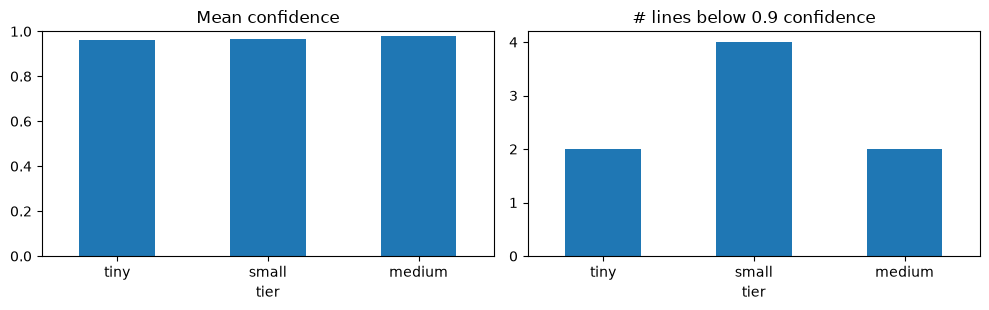

In [14]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(1, 2, figsize=(10, 3.2))
summary['mean_conf'].plot.bar(ax=ax[0], title='Mean confidence', rot=0, ylim=(0, 1))
summary['n_low_conf'].plot.bar(ax=ax[1], title=f'# lines below {LOW_CONF} confidence', rot=0)
plt.tight_layout(); plt.show()

## 8. Compare tiers on one document

Pick a document and print each tier's assembled text side by side, plus the
lines each tier was least sure about. This is where you eyeball *what actually
changes* between tiers — fixed misreads, dropped words, segmentation differences.

In [15]:
COMPARE_DOC = df['doc'].iloc[0]   # change to any doc name present in the results

sub = df[df['doc'] == COMPARE_DOC].set_index('tier').reindex(TIERS)
print(f'document: {COMPARE_DOC}\n')

for tier in TIERS:
    row = sub.loc[tier]
    print(f'================ {tier}  (lines={row.n_lines}, mean_conf={row.mean_conf:.3f}) ================')
    print(row.text)
    print()

document: 20201023- RELEASE ORDER_p001.png

================ tiny  (lines=39, mean_conf=0.963) ================
3
Republic of the Philippines
MUINICIPAL TRIAL COURT
Third Judicial Region
Sta. Rosa, Niueva Ecija
-0O0-
PEOPLE OF THE PHILIPPINES,
Plaintiff
-versus- CRIM. CASES NOS.09-20-6850 to
09-20-6882
MAYNARD R. CIRUZ and
EDMUNDO BASALL.O,
RELEASE ORDER
ACCUsed, MAYNARD R. CRUZ and EDMUNDO BASALLO,
through their respective, relatives posted cash bond in the amount of
THREE THOUSAND PESOS in each case or NINETY-NINE
THOUSAND PESOS for each accused, and for the thirty-three (33)
counts of c.ases for t:heir provisional liberty, which amount were
deposited with this Court under Official Receipts No. 7939568 and
7939569, respe.ctively all dated October 23, 2020, and finding the same
to be sufficient it? amount, forms and substance, the same are, as it
were, hereby APPROVED.
WHEREFORE, the? immediate release of MAYNARD R. CRUZ
and EDMUNDO BASAL.LO from custody of the Talavera Police Station